# Temporal Analysis

In [1]:
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import isodate

# ingestion path
CHANNELS_PATH = '../data/cleaned/cleaned_channels_info.csv'
VIDEOS_PATH = '../data/cleaned/cleaned_videos_info.csv'
COMMENTS_PATH = '../data/cleaned/cleaned_comments_info.csv'

# saving path
IMG_PATH = '../figs/temporal/'

In [2]:
def temporal_graphic(df: pd.DataFrame, y: str, ylabel: str, save_path: str):
    plt.figure(figsize=(3.5, 2.5))

    # graph
    sns.lineplot(
        data=df,
        x='period',
        y=y
    )

    # formatting
    plt.xlabel('Year')
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)

    # saving
    plt.tight_layout()
    plt.savefig(IMG_PATH + save_path)

In [3]:
# reading needed data
df_channels = pd.read_csv(CHANNELS_PATH, parse_dates=['published_at'])
df_videos = pd.read_csv(VIDEOS_PATH, parse_dates=['published_at'])
df_comments = pd.read_csv(COMMENTS_PATH, parse_dates=['published_at'])

## Videos


In [4]:
# grouping by year and aggregating video infos
df_videos['duration_seconds'] = df_videos['duration'].apply(
    lambda x: isodate.parse_duration(x).total_seconds()
)
df_videos['period'] = df_videos['published_at'].dt.to_period('Y').astype(str)
df_videos_yearly = df_videos.groupby('period').agg(
    {
        'video_id': 'nunique',
        'channel_id': 'nunique',
        'is_short': 'sum',
        'duration_seconds': 'sum'
    }
).reset_index()

df_videos_yearly['pct_shorts'] = (
    100 * df_videos_yearly['is_short']
    / df_videos_yearly['video_id']
)

df_videos_yearly['avg_duration_mins'] = (
    df_videos_yearly['duration_seconds']
    / df_videos_yearly['video_id'] / 60
)

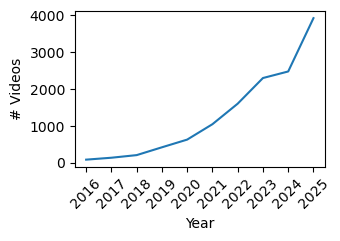

In [5]:
temporal_graphic(df_videos_yearly, 'video_id', '# Videos', 'yearly_video_count.png')

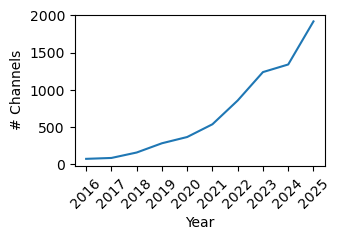

In [6]:
temporal_graphic(df_videos_yearly, 'channel_id', '# Channels', 'yearly_channel_count.png')

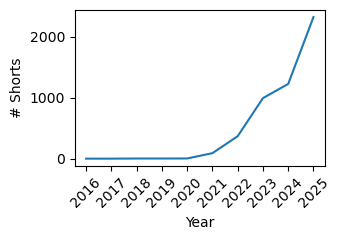

In [7]:
temporal_graphic(df_videos_yearly, 'is_short', '# Shorts', 'yearly_short_count.png')

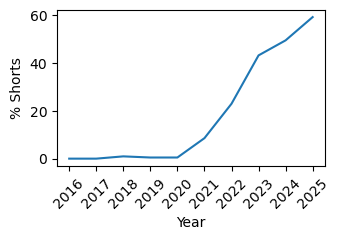

In [8]:
temporal_graphic(df_videos_yearly, 'pct_shorts', '% Shorts', 'yearly_short_pct.png')

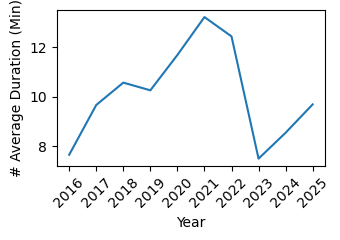

In [9]:
temporal_graphic(df_videos_yearly, 'avg_duration_mins', '# Average Duration (Min)', 'yearly_duration_avg.png')

## Comments

In [10]:
df_comments['period'] = df_comments['published_at'].dt.to_period('Y').astype(str)
df_comments_yearly = df_comments.groupby('period').agg(
    {
        'comment_id': 'nunique',
        'author_channel_id': 'nunique',
        'is_reply': 'sum',
        'like_count': 'sum'
    }
).reset_index()


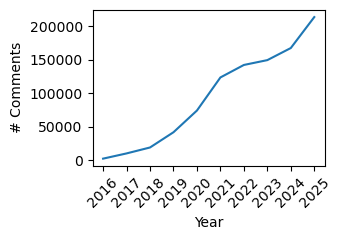

In [11]:
temporal_graphic(df_comments_yearly, 'comment_id', '# Comments', 'yearly_comment_count.png')

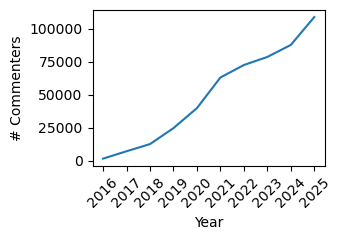

In [12]:
temporal_graphic(df_comments_yearly, 'author_channel_id', '# Commenters', 'yearly_commenters_count.png')

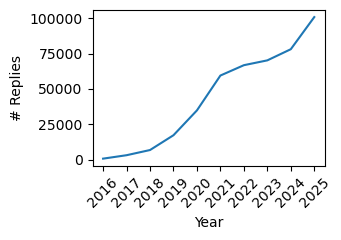

In [13]:
temporal_graphic(df_comments_yearly, 'is_reply', '# Replies', 'yearly_reply_count.png')

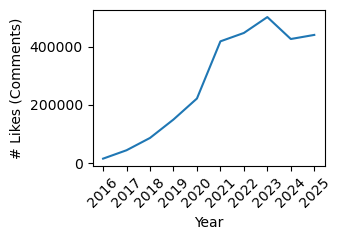

In [14]:
temporal_graphic(df_comments_yearly, 'like_count', '# Likes (Comments)', 'yearly_comment_like_count.png')